RUTAS E INSTALACIÓN DE PAQUETES

In [ ]:
from google.colab import drive

drive.mount(
    "/content/drive"
)

import os
import sys
import json
import random
import warnings

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["TF_DETERMINISTIC_OPS"] = "1"

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

import sklearn

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.model_selection import (
    StratifiedGroupKFold
)

from sklearn.utils.class_weight import (
    compute_class_weight
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)


warnings.filterwarnings(
    "ignore"
)



Mounted at /content/drive


In [ ]:
RUTA_DATOS = Path(
    "/content/drive/MyDrive/"
    "RNA_ENAPE/datos_RNA/enape_2021_bd_csv"
)

RUTA_TMODULO = (
    RUTA_DATOS
    / "TMODULO.csv"
)

RUTA_TVIVIENDA = (
    RUTA_DATOS
    / "TVIVIENDA.csv"
)


CARPETA_RESULTADOS = (
    RUTA_DATOS
    / "resultados_rna_100_epocas"
)

CARPETA_MODELOS = (
    CARPETA_RESULTADOS
    / "modelos"
)

CARPETA_HISTORIALES = (
    CARPETA_RESULTADOS
    / "historiales"
)

CARPETA_PREDICCIONES = (
    CARPETA_RESULTADOS
    / "predicciones"
)

CARPETA_GRAFICAS = (
    CARPETA_RESULTADOS
    / "graficas"
)

CARPETA_MATRICES = (
    CARPETA_RESULTADOS
    / "matrices_confusion"
)


for carpeta in [
    CARPETA_RESULTADOS,
    CARPETA_MODELOS,
    CARPETA_HISTORIALES,
    CARPETA_PREDICCIONES,
    CARPETA_GRAFICAS,
    CARPETA_MATRICES
]:
    carpeta.mkdir(
        parents=True,
        exist_ok=True
    )


if not RUTA_TMODULO.exists():
    raise FileNotFoundError(
        f"No se encontró:\n{RUTA_TMODULO}"
    )

if not RUTA_TVIVIENDA.exists():
    raise FileNotFoundError(
        f"No se encontró:\n{RUTA_TVIVIENDA}"
    )


print("Ruta de datos:")
print(RUTA_DATOS)

print("\nResultados:")
print(CARPETA_RESULTADOS)

Ruta de datos:
/content/drive/MyDrive/RNA_ENAPE/datos_RNA/enape_2021_bd_csv

Resultados:
/content/drive/MyDrive/RNA_ENAPE/datos_RNA/enape_2021_bd_csv/resultados_rna_100_epocas


Lectura de archivos y primer limpieza


In [ ]:
def leer_csv_inegi(
    ruta: Path
) -> pd.DataFrame:
    """
    Lee un archivo CSV intentando diferentes
    codificaciones y conserva todos los campos
    inicialmente como texto.
    """

    codificaciones = [
        "utf-8-sig",
        "utf-8",
        "latin-1"
    ]

    ultimo_error = None

    for codificacion in codificaciones:

        try:

            datos = pd.read_csv(
                ruta,
                dtype=str,
                encoding=codificacion,
                keep_default_na=False,
                low_memory=False
            )

            print(
                f"Archivo leído con {codificacion}: "
                f"{ruta.name}"
            )

            return datos

        except UnicodeDecodeError as error:
            ultimo_error = error

    raise UnicodeDecodeError(
        ultimo_error.encoding,
        ultimo_error.object,
        ultimo_error.start,
        ultimo_error.end,
        ultimo_error.reason
    )


def limpiar_texto(
    datos: pd.DataFrame
) -> pd.DataFrame:
    """
    Limpia nombres de columnas y espacios.
    Convierte cadenas vacías en valores ausentes.
    """

    datos = datos.copy()

    datos.columns = (
        datos.columns
        .str.strip()
        .str.upper()
    )

    for columna in datos.columns:

        datos[columna] = (
            datos[columna]
            .astype("string")
            .str.strip()
        )

        datos[columna] = (
            datos[columna]
            .replace({
                "": pd.NA,
                "NAN": pd.NA,
                "NONE": pd.NA,
                "<NA>": pd.NA
            })
        )

    return datos


def normalizar_codigo(
    datos: pd.DataFrame,
    columna: str,
    longitud: int
) -> None:
    """
    Agrega ceros a la izquierda cuando el campo
    contiene únicamente caracteres numéricos.
    """

    if columna not in datos.columns:
        return

    mascara = datos[columna].notna()

    valores = (
        datos.loc[
            mascara,
            columna
        ]
        .astype("string")
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )

    mascara_numerica = (
        valores
        .str.fullmatch(
            r"\d+"
        )
        .fillna(False)
    )

    indices = valores[
        mascara_numerica
    ].index

    datos.loc[
        indices,
        columna
    ] = (
        valores.loc[
            indices
        ]
        .str.zfill(
            longitud
        )
    )


tmodulo = leer_csv_inegi(
    RUTA_TMODULO
)

tvivienda = leer_csv_inegi(
    RUTA_TVIVIENDA
)


tmodulo = limpiar_texto(
    tmodulo
)

tvivienda = limpiar_texto(
    tvivienda
)


normalizar_codigo(
    tmodulo,
    "FOLIO",
    8
)

normalizar_codigo(
    tmodulo,
    "N_REN",
    2
)

normalizar_codigo(
    tvivienda,
    "FOLIO",
    8
)


for columna in [
    "PB3_2",
    "PA3_5",
    "NIVEL_A"
]:
    normalizar_codigo(
        tmodulo,
        columna,
        2
    )


for columna in [
    "P1_5",
    "ENT"
]:
    normalizar_codigo(
        tvivienda,
        columna,
        2
    )


print("\nDimensión de TMODULO:")
print(tmodulo.shape)

print("\nDimensión de TVIVIENDA:")
print(tvivienda.shape)

Archivo leído con utf-8-sig: TMODULO.csv
Archivo leído con utf-8-sig: TVIVIENDA.csv

Dimensión de TMODULO:
(32343, 101)

Dimensión de TVIVIENDA:
(22719, 17)


Validación de variables


In [ ]:
COLUMNAS_TMODULO = [
    "FOLIO",
    "N_REN",
    "SEXO",
    "EDAD",
    "PA3_1",
    "PA3_2",
    "NIVEL_A",
    "GRADO_A",
    "PA3_4",
    "PA3_5",
    "PA3_6",
    "PA3_7_1",
    "PA3_7_2",
    "PA3_7_3",
    "PA3_8_1",
    "PA3_8_2",
    "PA3_8_3",
    "PA3_8_4",
    "PA3_8_5",
    "PA3_8_6",
    "PA3_8_7",
    "PA3_8_8",
    "PB3_1",
    "PB3_2",
    "PB3_6",
    "FACTOR"
]


COLUMNAS_TVIVIENDA = [
    "FOLIO",
    "P1_4_1",
    "P1_4_2",
    "P1_4_3",
    "P1_4_4",
    "P1_4_5",
    "P1_4_6",
    "P1_5",
    "ENT"
]


def validar_columnas(
    datos: pd.DataFrame,
    columnas: list,
    nombre_archivo: str
) -> None:

    faltantes = [
        columna
        for columna in columnas
        if columna not in datos.columns
    ]

    if faltantes:

        raise KeyError(
            f"Faltan columnas en {nombre_archivo}:\n"
            f"{faltantes}"
        )


validar_columnas(
    tmodulo,
    COLUMNAS_TMODULO,
    "TMODULO"
)

validar_columnas(
    tvivienda,
    COLUMNAS_TVIVIENDA,
    "TVIVIENDA"
)


duplicados_vivienda = (
    tvivienda
    .duplicated(
        subset=["FOLIO"],
        keep=False
    )
    .sum()
)

duplicados_persona = (
    tmodulo
    .duplicated(
        subset=[
            "FOLIO",
            "N_REN"
        ],
        keep=False
    )
    .sum()
)


print(
    "Duplicados por FOLIO en TVIVIENDA:",
    duplicados_vivienda
)

print(
    "Duplicados por FOLIO + N_REN en TMODULO:",
    duplicados_persona
)


if duplicados_vivienda > 0:

    raise ValueError(
        "TVIVIENDA contiene más de una fila "
        "para un mismo FOLIO."
    )


if duplicados_persona > 0:

    raise ValueError(
        "TMODULO contiene más de una fila "
        "para una misma persona."
    )


print(
    "\nValidación de llaves concluida correctamente."
)

Duplicados por FOLIO en TVIVIENDA: 0
Duplicados por FOLIO + N_REN en TMODULO: 0

Validación de llaves concluida correctamente.


Cohorte, union de archivos y variable objetivo (reglas)

In [ ]:
tm_seleccionado = (
    tmodulo[
        COLUMNAS_TMODULO
    ]
    .copy()
)

tv_seleccionado = (
    tvivienda[
        COLUMNAS_TVIVIENDA
    ]
    .copy()
)


tm_seleccionado["EDAD"] = (
    pd.to_numeric(
        tm_seleccionado["EDAD"],
        errors="coerce"
    )
)


cohorte = (
    tm_seleccionado[
        (
            tm_seleccionado["EDAD"]
            .between(
                3,
                29
            )
        )
        &
        (
            tm_seleccionado["PA3_1"]
            == "1"
        )
    ]
    .copy()
)


print(
    "Personas de 3 a 29 años inscritas "
    "en 2020-2021:",
    len(cohorte)
)

tv_seleccionado = (
    tv_seleccionado
    .rename(
        columns={
            "ENT":
                "ENTIDAD"
        }
    )
)

base = cohorte.merge(
    tv_seleccionado,
    on="FOLIO",
    how="left",
    validate="many_to_one",
    indicator=True
)


conteo_union = (
    base["_merge"]
    .value_counts(
        dropna=False
    )
)

print("\nResultado de la unión:")
print(conteo_union)


if not (
    base["_merge"]
    == "both"
).all():

    casos_sin_vivienda = (
        base[
            base["_merge"]
            != "both"
        ]
        .copy()
    )

    casos_sin_vivienda.to_csv(
        CARPETA_RESULTADOS
        / "casos_sin_vivienda.csv",
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "Existen personas sin correspondencia "
        "en TVIVIENDA."
    )


base = base.drop(
    columns="_merge"
)

base["OBJETIVO"] = pd.Series(
    pd.NA,
    index=base.index,
    dtype="Int8"
)

condicion_continuidad = (
    (
        base["PB3_1"]
        == "1"
    )
    &
    (
        base["PB3_6"]
        .isin([
            "1",
            "2",
            "3"
        ])
    )
)

condicion_baja = (
    (
        base["PB3_1"]
        == "1"
    )
    &
    (
        base["PB3_6"]
        == "4"
    )
)

CODIGOS_NO_CONTINUIDAD = {
    f"{codigo:02d}"
    for codigo in range(
        1,
        17
    )
}

CODIGOS_NO_CONTINUIDAD.remove(
    "04"
)


condicion_no_inscripcion = (
    (
        base["PB3_1"]
        == "2"
    )
    &
    (
        base["PB3_2"]
        .isin(
            CODIGOS_NO_CONTINUIDAD
        )
    )
)


base.loc[
    condicion_continuidad,
    "OBJETIVO"
] = 1

base.loc[
    condicion_baja
    |
    condicion_no_inscripcion,
    "OBJETIVO"
] = 0

casos_sin_clasificar = (
    base[
        base["OBJETIVO"]
        .isna()
    ]
    .copy()
)


if len(
    casos_sin_clasificar
) > 0:

    casos_sin_clasificar.to_csv(
        CARPETA_RESULTADOS
        / "casos_sin_clasificar.csv",
        index=False,
        encoding="utf-8-sig"
    )


print(
    "\nCasos sin clasificación:",
    len(casos_sin_clasificar)
)

base = (
    base[
        base["OBJETIVO"]
        .notna()
    ]
    .copy()
)


base["OBJETIVO"] = (
    base["OBJETIVO"]
    .astype("int8")
)


base["RIESGO"] = (
    1
    - base["OBJETIVO"]
).astype("int8")


print(
    "\nDistribución de OBJETIVO:"
)

print(
    base["OBJETIVO"]
    .value_counts()
    .sort_index()
)


print(
    "\nDistribución de RIESGO:"
)

print(
    base["RIESGO"]
    .value_counts()
    .sort_index()
)


print(
    "\nPorcentajes de RIESGO:"
)

print(
    (
        base["RIESGO"]
        .value_counts(
            normalize=True
        )
        .sort_index()
        * 100
    )
    .round(2)
)

Personas de 3 a 29 años inscritas en 2020-2021: 20064

Resultado de la unión:
_merge
both          20064
left_only         0
right_only        0
Name: count, dtype: int64

Casos sin clasificación: 521

Distribución de OBJETIVO:
OBJETIVO
0     1220
1    18323
Name: count, dtype: int64

Distribución de RIESGO:
RIESGO
0    18323
1     1220
Name: count, dtype: int64

Porcentajes de RIESGO:
RIESGO
0    93.76
1     6.24
Name: proportion, dtype: float64


Ajuste de variables

In [ ]:
def convertir_categoria(
    serie: pd.Series
) -> pd.Series:
    """
    Convierte una variable a texto y distingue
    los campos vacíos mediante NO_APLICA.
    """

    return (
        serie
        .astype("string")
        .fillna("NO_APLICA")
        .replace({
            "":
                "NO_APLICA"
        })
    )
categoricas_originales = [
    "ENTIDAD",
    "SEXO",
    "PA3_2",
    "NIVEL_A",
    "GRADO_A",
    "PA3_4",
    "PA3_5",
    "PA3_6",
    "PA3_7_1",
    "PA3_7_2",
    "PA3_7_3",
    "PA3_8_1",
    "PA3_8_2",
    "PA3_8_3",
    "PA3_8_4",
    "PA3_8_5",
    "PA3_8_6",
    "PA3_8_7",
    "PA3_8_8",
    "P1_4_1",
    "P1_4_2",
    "P1_4_3",
    "P1_4_4",
    "P1_4_5",
    "P1_4_6",
    "P1_5"
]


for columna in categoricas_originales:

    base[columna] = convertir_categoria(
        base[columna]
    )

base["TRAYECTORIA_A"] = (
    "CONCLUSION_"
    + base["PA3_4"]
    + "__RESULTADO_"
    + base["PA3_6"]
)

base["FACTOR"] = pd.to_numeric(
    base["FACTOR"],
    errors="coerce"
)

VARIABLE_NUMERICA = [
    "EDAD"
]


VARIABLES_CATEGORICAS = [
    "ENTIDAD",
    "SEXO",
    "PA3_2",
    "NIVEL_A",
    "GRADO_A",
    "TRAYECTORIA_A",
    "PA3_5",
    "PA3_7_1",
    "PA3_7_2",
    "PA3_7_3",
    "PA3_8_1",
    "PA3_8_2",
    "PA3_8_3",
    "PA3_8_4",
    "PA3_8_5",
    "PA3_8_6",
    "PA3_8_7",
    "PA3_8_8",
    "P1_4_1",
    "P1_4_2",
    "P1_4_3",
    "P1_4_4",
    "P1_4_5",
    "P1_4_6",
    "P1_5"
]


VARIABLES_PREDICTORAS = (
    VARIABLE_NUMERICA
    + VARIABLES_CATEGORICAS
)

if base["EDAD"].isna().any():

    raise ValueError(
        "La variable EDAD contiene valores ausentes "
        "dentro de la cohorte analítica."
    )


columnas_auditoria = [
    "FOLIO",
    "N_REN",
    "OBJETIVO",
    "RIESGO",
    "FACTOR"
]


base_analitica = (
    base[
        columnas_auditoria
        + VARIABLES_PREDICTORAS
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


if (
    base_analitica[
        VARIABLES_CATEGORICAS
    ]
    .isna()
    .any()
    .any()
):

    raise ValueError(
        "Todavía existen valores ausentes "
        "en las variables categóricas."
    )


if (
    base_analitica
    .duplicated(
        subset=[
            "FOLIO",
            "N_REN"
        ]
    )
    .any()
):

    raise ValueError(
        "La base analítica contiene personas duplicadas."
    )


ruta_base_analitica = (
    CARPETA_RESULTADOS
    / "base_analitica_auditoria.csv"
)

base_analitica.to_csv(
    ruta_base_analitica,
    index=False,
    encoding="utf-8-sig"
)


print(
    "Dimensión de la base analítica:",
    base_analitica.shape
)

print(
    "Viviendas diferentes:",
    base_analitica["FOLIO"]
    .nunique()
)

print(
    "Predictores originales:",
    len(VARIABLES_PREDICTORAS)
)

print(
    "\nBase analítica guardada en:"
)

print(ruta_base_analitica)

Dimensión de la base analítica: (19543, 31)
Viviendas diferentes: 11146
Predictores originales: 26

Base analítica guardada en:
/content/drive/MyDrive/RNA_ENAPE/datos_RNA/enape_2021_bd_csv/resultados_rna_100_epocas/base_analitica_auditoria.csv


Dividir entrenamiento, validación y prueba por vivienda

In [ ]:

SEMILLA_PARTICION = 42


indices_totales = np.arange(
    len(base_analitica)
)

separador_prueba = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEMILLA_PARTICION
)


indices_entrenamiento_validacion, indices_prueba = next(
    separador_prueba.split(
        X=indices_totales,
        y=base_analitica["RIESGO"],
        groups=base_analitica["FOLIO"]
    )
)


base_entrenamiento_validacion = (
    base_analitica
    .iloc[
        indices_entrenamiento_validacion
    ]
)

separador_validacion = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=SEMILLA_PARTICION
)


indices_locales = np.arange(
    len(base_entrenamiento_validacion)
)


indices_entrenamiento_locales, indices_validacion_locales = next(
    separador_validacion.split(
        X=indices_locales,
        y=base_entrenamiento_validacion["RIESGO"],
        groups=base_entrenamiento_validacion["FOLIO"]
    )
)


indices_entrenamiento = (
    indices_entrenamiento_validacion[
        indices_entrenamiento_locales
    ]
)

indices_validacion = (
    indices_entrenamiento_validacion[
        indices_validacion_locales
    ]
)


entrenamiento = (
    base_analitica
    .iloc[
        indices_entrenamiento
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

validacion = (
    base_analitica
    .iloc[
        indices_validacion
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

prueba = (
    base_analitica
    .iloc[
        indices_prueba
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

folios_entrenamiento = set(
    entrenamiento["FOLIO"]
)

folios_validacion = set(
    validacion["FOLIO"]
)

folios_prueba = set(
    prueba["FOLIO"]
)


if (
    folios_entrenamiento
    & folios_validacion
):

    raise ValueError(
        "Hay viviendas compartidas entre "
        "entrenamiento y validación."
    )


if (
    folios_entrenamiento
    & folios_prueba
):

    raise ValueError(
        "Hay viviendas compartidas entre "
        "entrenamiento y prueba."
    )


if (
    folios_validacion
    & folios_prueba
):

    raise ValueError(
        "Hay viviendas compartidas entre "
        "validación y prueba."
    )

asignacion_particiones = pd.concat(
    [
        entrenamiento[
            [
                "FOLIO",
                "N_REN",
                "RIESGO"
            ]
        ].assign(
            PARTICION="ENTRENAMIENTO"
        ),

        validacion[
            [
                "FOLIO",
                "N_REN",
                "RIESGO"
            ]
        ].assign(
            PARTICION="VALIDACION"
        ),

        prueba[
            [
                "FOLIO",
                "N_REN",
                "RIESGO"
            ]
        ].assign(
            PARTICION="PRUEBA"
        )
    ],
    ignore_index=True
)


asignacion_particiones.to_csv(
    CARPETA_RESULTADOS
    / "asignacion_particiones.csv",
    index=False,
    encoding="utf-8-sig"
)

def obtener_distribucion(
    datos: pd.DataFrame,
    particion: str
) -> pd.DataFrame:

    conteos = (
        datos["RIESGO"]
        .value_counts()
        .reindex(
            [0, 1],
            fill_value=0
        )
    )

    total = len(datos)

    return pd.DataFrame({
        "PARTICION": [
            particion,
            particion
        ],

        "RIESGO": [
            0,
            1
        ],

        "CLASE": [
            "CONTINUIDAD",
            "NO_CONTINUIDAD"
        ],

        "REGISTROS": [
            int(conteos.loc[0]),
            int(conteos.loc[1])
        ],

        "PORCENTAJE": [
            (
                conteos.loc[0]
                / total
                * 100
            ),
            (
                conteos.loc[1]
                / total
                * 100
            )
        ]
    })


tabla_distribucion = pd.concat(
    [
        obtener_distribucion(
            entrenamiento,
            "ENTRENAMIENTO"
        ),

        obtener_distribucion(
            validacion,
            "VALIDACION"
        ),

        obtener_distribucion(
            prueba,
            "PRUEBA"
        )
    ],
    ignore_index=True
)


tabla_distribucion.to_csv(
    CARPETA_RESULTADOS
    / "distribucion_clases_particiones.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    "Entrenamiento:",
    entrenamiento.shape
)

print(
    "Validación:",
    validacion.shape
)

print(
    "Prueba:",
    prueba.shape
)


print("\nDistribución de clases:")

print(
    tabla_distribucion
    .round(2)
    .to_string(
        index=False
    )
)

Entrenamiento: (11799, 31)
Validación: (3901, 31)
Prueba: (3843, 31)

Distribución de clases:
    PARTICION  RIESGO          CLASE  REGISTROS  PORCENTAJE
ENTRENAMIENTO       0    CONTINUIDAD      11064       93.77
ENTRENAMIENTO       1 NO_CONTINUIDAD        735        6.23
   VALIDACION       0    CONTINUIDAD       3648       93.51
   VALIDACION       1 NO_CONTINUIDAD        253        6.49
       PRUEBA       0    CONTINUIDAD       3611       93.96
       PRUEBA       1 NO_CONTINUIDAD        232        6.04


Codificación y normalización

In [ ]:

try:

    codificador_one_hot = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
        dtype=np.float32
    )

except TypeError:

    codificador_one_hot = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False,
        dtype=np.float32
    )

preprocesador = ColumnTransformer(
    transformers=[
        (
            "edad_estandarizada",
            StandardScaler(),
            VARIABLE_NUMERICA
        ),

        (
            "categoricas_one_hot",
            codificador_one_hot,
            VARIABLES_CATEGORICAS
        )
    ],

    remainder="drop",

    verbose_feature_names_out=False
)

X_train = preprocesador.fit_transform(
    entrenamiento[
        VARIABLES_PREDICTORAS
    ]
)

X_val = preprocesador.transform(
    validacion[
        VARIABLES_PREDICTORAS
    ]
)

X_test = preprocesador.transform(
    prueba[
        VARIABLES_PREDICTORAS
    ]
)


X_train = np.asarray(
    X_train,
    dtype=np.float32
)

X_val = np.asarray(
    X_val,
    dtype=np.float32
)

X_test = np.asarray(
    X_test,
    dtype=np.float32
)


y_train = (
    entrenamiento["RIESGO"]
    .to_numpy(
        dtype=np.int32
    )
)

y_val = (
    validacion["RIESGO"]
    .to_numpy(
        dtype=np.int32
    )
)

y_test = (
    prueba["RIESGO"]
    .to_numpy(
        dtype=np.int32
    )
)

nombres_predictores = (
    preprocesador
    .get_feature_names_out()
)


pd.DataFrame({
    "PREDICTOR_CODIFICADO":
        nombres_predictores
}).to_csv(
    CARPETA_RESULTADOS
    / "nombres_predictores_codificados.csv",
    index=False,
    encoding="utf-8-sig"
)

joblib.dump(
    preprocesador,
    CARPETA_RESULTADOS
    / "preprocesador.joblib"
)

np.save(
    CARPETA_RESULTADOS
    / "X_train.npy",
    X_train
)

np.save(
    CARPETA_RESULTADOS
    / "X_val.npy",
    X_val
)

np.save(
    CARPETA_RESULTADOS
    / "X_test.npy",
    X_test
)

np.save(
    CARPETA_RESULTADOS
    / "y_train.npy",
    y_train
)

np.save(
    CARPETA_RESULTADOS
    / "y_val.npy",
    y_val
)

np.save(
    CARPETA_RESULTADOS
    / "y_test.npy",
    y_test
)

clases = np.array(
    [0, 1],
    dtype=np.int32
)


valores_pesos = compute_class_weight(
    class_weight="balanced",
    classes=clases,
    y=y_train
)


pesos_clase = {
    int(clase):
        float(peso)

    for clase, peso
    in zip(
        clases,
        valores_pesos
    )
}


with open(
    CARPETA_RESULTADOS
    / "pesos_clase.json",
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        {
            str(clase):
                peso

            for clase, peso
            in pesos_clase.items()
        },
        archivo,
        indent=4,
        ensure_ascii=False
    )


print(
    "X_train:",
    X_train.shape
)

print(
    "X_val:",
    X_val.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "\nNúmero de predictores codificados:",
    X_train.shape[1]
)

print(
    "\nPesos de clase:",
    pesos_clase
)

X_train: (11799, 136)
X_val: (3901, 136)
X_test: (3843, 136)

Número de predictores codificados: 136

Pesos de clase: {0: 0.5332158351409978, 1: 8.026530612244898}


Funciones de evaluacion

In [ ]:
UMBRAL_DECISION = 0.50


def calcular_metricas(
    y_real: np.ndarray,
    probabilidades: np.ndarray,
    umbral: float = UMBRAL_DECISION
):
    """
    Calcula métricas considerando:
    0 = continuidad
    1 = no continuidad
    """

    y_real = np.asarray(
        y_real,
        dtype=np.int32
    )

    probabilidades = np.asarray(
        probabilidades,
        dtype=np.float64
    ).ravel()


    predicciones = (
        probabilidades
        >= umbral
    ).astype(
        np.int32
    )


    matriz = confusion_matrix(
        y_real,
        predicciones,
        labels=[
            0,
            1
        ]
    )


    tn, fp, fn, tp = (
        matriz.ravel()
    )


    especificidad = (
        tn
        / (
            tn
            + fp
        )
        if (
            tn
            + fp
        ) > 0
        else 0.0
    )


    if len(
        np.unique(
            y_real
        )
    ) == 2:

        roc_auc = roc_auc_score(
            y_real,
            probabilidades
        )

        average_precision = (
            average_precision_score(
                y_real,
                probabilidades
            )
        )

    else:

        roc_auc = np.nan
        average_precision = np.nan


    metricas = {
        "N":
            int(
                len(y_real)
            ),

        "UMBRAL":
            float(
                umbral
            ),

        "AVERAGE_PRECISION":
            float(
                average_precision
            ),

        "ROC_AUC":
            float(
                roc_auc
            ),

        "PRECISION_RIESGO":
            float(
                precision_score(
                    y_real,
                    predicciones,
                    pos_label=1,
                    zero_division=0
                )
            ),

        "RECALL_RIESGO":
            float(
                recall_score(
                    y_real,
                    predicciones,
                    pos_label=1,
                    zero_division=0
                )
            ),

        "ESPECIFICIDAD":
            float(
                especificidad
            ),

        "F1_RIESGO":
            float(
                f1_score(
                    y_real,
                    predicciones,
                    pos_label=1,
                    zero_division=0
                )
            ),

        "F1_MACRO":
            float(
                f1_score(
                    y_real,
                    predicciones,
                    average="macro",
                    zero_division=0
                )
            ),

        "BALANCED_ACCURACY":
            float(
                balanced_accuracy_score(
                    y_real,
                    predicciones
                )
            ),

        "ACCURACY":
            float(
                accuracy_score(
                    y_real,
                    predicciones
                )
            ),

        "TN":
            int(tn),

        "FP":
            int(fp),

        "FN":
            int(fn),

        "TP":
            int(tp),

        "POSITIVOS_REALES":
            int(
                np.sum(
                    y_real == 1
                )
            ),

        "POSITIVOS_PREDICHOS":
            int(
                np.sum(
                    predicciones == 1
                )
            )
    }


    return (
        metricas,
        predicciones,
        matriz
    )

probabilidades_base_val = np.zeros(
    len(y_val),
    dtype=np.float32
)

probabilidades_base_test = np.zeros(
    len(y_test),
    dtype=np.float32
)


metricas_base_val, _, _ = calcular_metricas(
    y_val,
    probabilidades_base_val,
    UMBRAL_DECISION
)

metricas_base_test, _, _ = calcular_metricas(
    y_test,
    probabilidades_base_test,
    UMBRAL_DECISION
)

tabla_linea_base = pd.DataFrame(
    [
        {
            "CONJUNTO":
                "VALIDACION",
            **metricas_base_val
        },

        {
            "CONJUNTO":
                "PRUEBA",
            **metricas_base_test
        }
    ]
)


tabla_linea_base.to_csv(
    CARPETA_RESULTADOS
    / "linea_base_clase_mayoritaria.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    "Línea base de clase mayoritaria:"
)

print(
    tabla_linea_base[
        [
            "CONJUNTO",
            "AVERAGE_PRECISION",
            "RECALL_RIESGO",
            "F1_RIESGO",
            "BALANCED_ACCURACY",
            "ACCURACY"
        ]
    ]
    .round(4)
    .to_string(
        index=False
    )
)

Línea base de clase mayoritaria:
  CONJUNTO  AVERAGE_PRECISION  RECALL_RIESGO  F1_RIESGO  BALANCED_ACCURACY  ACCURACY
VALIDACION             0.0649            0.0        0.0                0.5    0.9351
    PRUEBA             0.0604            0.0        0.0                0.5    0.9396


Definir la red y las funciones de activación

In [ ]:

SEMILLA_MODELO = 42

NUMERO_EPOCAS = 100
TAMANIO_LOTE = 128
TASA_APRENDIZAJE = 0.001


ACTIVACIONES = [
    "sigmoid",
    "tanh",
    "relu",
    "leaky_relu",
    "prelu",
    "rrelu",
    "elu",
    "selu",
    "swish",
    "gelu"
]

def fijar_semilla(
    semilla: int
) -> None:

    os.environ[
        "PYTHONHASHSEED"
    ] = str(
        semilla
    )

    random.seed(
        semilla
    )

    np.random.seed(
        semilla
    )

    tf.keras.utils.set_random_seed(
        semilla
    )

    try:

        tf.config.experimental.enable_op_determinism()

    except Exception:
        pass

@keras.utils.register_keras_serializable(
    package="ENAPE"
)
class RReLU(layers.Layer):

    def __init__(
        self,
        lower: float = 1.0 / 8.0,
        upper: float = 1.0 / 3.0,
        seed: int = 42,
        **kwargs
    ):

        super().__init__(
            **kwargs
        )

        if lower < 0:

            raise ValueError(
                "lower debe ser mayor "
                "o igual que cero."
            )

        if upper <= lower:

            raise ValueError(
                "upper debe ser mayor "
                "que lower."
            )

        self.lower = float(
            lower
        )

        self.upper = float(
            upper
        )

        self.seed = int(
            seed
        )


    def call(
        self,
        inputs,
        training=None
    ):

        inputs = tf.convert_to_tensor(
            inputs
        )


        def salida_entrenamiento():

            alpha = tf.random.uniform(
                shape=tf.shape(
                    inputs
                ),
                minval=self.lower,
                maxval=self.upper,
                dtype=inputs.dtype,
                seed=self.seed
            )

            return tf.where(
                inputs >= 0,
                inputs,
                alpha * inputs
            )


        def salida_evaluacion():

            alpha_promedio = tf.cast(
                (
                    self.lower
                    + self.upper
                )
                / 2.0,
                dtype=inputs.dtype
            )

            return tf.where(
                inputs >= 0,
                inputs,
                alpha_promedio
                * inputs
            )


        if training is None:
            training = False


        if isinstance(
            training,
            (
                bool,
                np.bool_
            )
        ):

            if training:
                return salida_entrenamiento()

            return salida_evaluacion()


        return tf.cond(
            tf.cast(
                training,
                tf.bool
            ),
            salida_entrenamiento,
            salida_evaluacion
        )


    def get_config(self):

        configuracion = (
            super()
            .get_config()
        )

        configuracion.update({
            "lower":
                self.lower,

            "upper":
                self.upper,

            "seed":
                self.seed
        })

        return configuracion

def aplicar_activacion(
    tensor,
    activacion: str,
    nombre: str,
    semilla: int
):

    if activacion == "leaky_relu":

        return layers.LeakyReLU(
            negative_slope=0.01,
            name=nombre
        )(tensor)


    if activacion == "prelu":

        return layers.PReLU(
            alpha_initializer=(
                keras.initializers.Constant(
                    0.25
                )
            ),


            shared_axes=[
                1
            ],

            name=nombre
        )(tensor)


    if activacion == "rrelu":

        return RReLU(
            lower=1.0 / 8.0,
            upper=1.0 / 3.0,
            seed=semilla,
            name=nombre
        )(tensor)


    if activacion == "gelu":

        return layers.Activation(
            activation=(
                keras.activations.gelu
            ),
            name=nombre
        )(tensor)


    if activacion == "swish":

        return layers.Activation(
            activation=(
                keras.activations.swish
            ),
            name=nombre
        )(tensor)


    return layers.Activation(
        activation=activacion,
        name=nombre
    )(tensor)

def crear_modelo(
    numero_predictores: int,
    activacion: str,
    semilla: int = SEMILLA_MODELO
) -> keras.Model:

    keras.backend.clear_session()

    fijar_semilla(
        semilla
    )


    entrada = keras.Input(
        shape=(
            numero_predictores,
        ),
        name="entrada"
    )


    x = layers.Dense(
        units=64,
        activation=None,

        kernel_initializer=(
            keras.initializers.GlorotUniform(
                seed=semilla
            )
        ),

        name="capa_densa_1"
    )(entrada)


    x = aplicar_activacion(
        tensor=x,
        activacion=activacion,
        nombre=(
            f"activacion_1_"
            f"{activacion}"
        ),
        semilla=semilla + 10
    )


    x = layers.Dense(
        units=32,
        activation=None,

        kernel_initializer=(
            keras.initializers.GlorotUniform(
                seed=semilla + 1
            )
        ),

        name="capa_densa_2"
    )(x)


    x = aplicar_activacion(
        tensor=x,
        activacion=activacion,
        nombre=(
            f"activacion_2_"
            f"{activacion}"
        ),
        semilla=semilla + 20
    )


    salida = layers.Dense(
        units=1,
        activation="sigmoid",

        kernel_initializer=(
            keras.initializers.GlorotUniform(
                seed=semilla + 2
            )
        ),

        name="salida_riesgo"
    )(x)


    modelo = keras.Model(
        inputs=entrada,
        outputs=salida,
        name=(
            f"RNA_{activacion}"
        )
    )


    modelo.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=(
                TASA_APRENDIZAJE
            )
        ),

        loss=(
            "binary_crossentropy"
        ),

        metrics=[
            keras.metrics.BinaryAccuracy(
                name="accuracy",
                threshold=(
                    UMBRAL_DECISION
                )
            ),

            keras.metrics.Precision(
                name="precision_riesgo",
                thresholds=(
                    UMBRAL_DECISION
                )
            ),

            keras.metrics.Recall(
                name="recall_riesgo",
                thresholds=(
                    UMBRAL_DECISION
                )
            ),

            keras.metrics.AUC(
                name="roc_auc_keras",
                curve="ROC"
            ),

            keras.metrics.AUC(
                name="pr_auc_keras",
                curve="PR"
            )
        ]
    )


    return modelo

modelo_prueba = crear_modelo(
    numero_predictores=(
        X_train.shape[1]
    ),
    activacion="relu",
    semilla=SEMILLA_MODELO
)


modelo_prueba.summary()


del modelo_prueba

keras.backend.clear_session()

Model: "RNA_relu"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 136)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_densa_1 (Dense)            │ (None, 64)             │         8,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activacion_1_relu (Activation)  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_densa_2 (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activacion_2_relu (Activation)  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_riesgo (Dense)           │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,881 (42.50 KB)

 Trainable params: 10,881 (42.50 KB)

 Non-trainable params: 0 (0.00 B)

Entrenar

In [ ]:
resultados_validacion = []

rutas_modelos = {}

probabilidades_modelos_val = {}


orden_activaciones = {
    activacion:
        posicion

    for posicion, activacion
    in enumerate(
        ACTIVACIONES
    )
}


for activacion in ACTIVACIONES:

    print(
        "\n"
        + "=" * 65
    )

    print(
        "ENTRENANDO ACTIVACIÓN:",
        activacion.upper()
    )

    print(
        "=" * 65
    )


    modelo = crear_modelo(
        numero_predictores=(
            X_train.shape[1]
        ),
        activacion=activacion,
        semilla=SEMILLA_MODELO
    )

    historial = modelo.fit(
        X_train,
        y_train,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=NUMERO_EPOCAS,

        batch_size=(
            TAMANIO_LOTE
        ),

        class_weight=(
            pesos_clase
        ),

        shuffle=True,

        verbose=0
    )


    epocas_ejecutadas = len(
        historial.history[
            "loss"
        ]
    )


    if epocas_ejecutadas != NUMERO_EPOCAS:

        raise RuntimeError(
            f"El modelo {activacion} ejecutó "
            f"{epocas_ejecutadas} épocas "
            f"en lugar de {NUMERO_EPOCAS}."
        )


    if not np.isfinite(
        historial.history[
            "loss"
        ]
    ).all():

        raise FloatingPointError(
            f"Se detectaron valores no finitos "
            f"en {activacion}."
        )

    probabilidades_val = (
        modelo.predict(
            X_val,
            verbose=0
        )
        .ravel()
    )


    (
        metricas_val,
        predicciones_val,
        matriz_val
    ) = calcular_metricas(
        y_real=y_val,
        probabilidades=(
            probabilidades_val
        ),
        umbral=UMBRAL_DECISION
    )


    metricas_val[
        "ACTIVACION"
    ] = activacion

    metricas_val[
        "EPOCAS_EJECUTADAS"
    ] = epocas_ejecutadas

    metricas_val[
        "LOSS_FINAL_ENTRENAMIENTO"
    ] = float(
        historial.history[
            "loss"
        ][-1]
    )

    metricas_val[
        "LOSS_FINAL_VALIDACION"
    ] = float(
        historial.history[
            "val_loss"
        ][-1]
    )

    metricas_val[
        "PR_AUC_KERAS_FINAL_VALIDACION"
    ] = float(
        historial.history[
            "val_pr_auc_keras"
        ][-1]
    )


    resultados_validacion.append(
        metricas_val
    )


    probabilidades_modelos_val[
        activacion
    ] = probabilidades_val

    ruta_modelo = (
        CARPETA_MODELOS
        / f"modelo_{activacion}.keras"
    )


    modelo.save(
        ruta_modelo
    )


    rutas_modelos[
        activacion
    ] = ruta_modelo

    ruta_historial = (
        CARPETA_HISTORIALES
        / f"historial_{activacion}.csv"
    )


    pd.DataFrame(
        historial.history
    ).to_csv(
        ruta_historial,
        index=False,
        encoding="utf-8-sig"
    )


    predicciones_validacion = pd.DataFrame({
        "FOLIO":
            validacion["FOLIO"],

        "N_REN":
            validacion["N_REN"],

        "OBJETIVO_ORIGINAL":
            validacion["OBJETIVO"],

        "RIESGO_REAL":
            y_val,

        "ACTIVACION":
            activacion,

        "PROBABILIDAD_NO_CONTINUIDAD":
            probabilidades_val,

        "UMBRAL":
            UMBRAL_DECISION,

        "PREDICCION_RIESGO":
            predicciones_val,

        "PREDICCION_OBJETIVO":
            (
                1
                - predicciones_val
            )
    })


    predicciones_validacion.to_csv(
        CARPETA_PREDICCIONES
        / (
            "predicciones_validacion_"
            f"{activacion}.csv"
        ),
        index=False,
        encoding="utf-8-sig"
    )

    matriz_val_df = pd.DataFrame(
        matriz_val,

        index=[
            "REAL_CONTINUIDAD",
            "REAL_NO_CONTINUIDAD"
        ],

        columns=[
            "PRED_CONTINUIDAD",
            "PRED_NO_CONTINUIDAD"
        ]
    )


    matriz_val_df.to_csv(
        CARPETA_MATRICES
        / (
            "matriz_validacion_"
            f"{activacion}.csv"
        ),
        encoding="utf-8-sig"
    )


    print(
        "Épocas ejecutadas:",
        epocas_ejecutadas
    )

    print(
        "Average Precision validación:",
        round(
            metricas_val[
                "AVERAGE_PRECISION"
            ],
            4
        )
    )

    print(
        "ROC-AUC validación:",
        round(
            metricas_val[
                "ROC_AUC"
            ],
            4
        )
    )

    print(
        "Recall de no continuidad:",
        round(
            metricas_val[
                "RECALL_RIESGO"
            ],
            4
        )
    )

    print(
        "F1 de no continuidad:",
        round(
            metricas_val[
                "F1_RIESGO"
            ],
            4
        )
    )


    del modelo
    del historial

    keras.backend.clear_session()

tabla_validacion = pd.DataFrame(
    resultados_validacion
)


tabla_validacion[
    "ORDEN"
] = (
    tabla_validacion[
        "ACTIVACION"
    ]
    .map(
        orden_activaciones
    )
)


tabla_validacion = (
    tabla_validacion
    .sort_values(
        "ORDEN"
    )
    .drop(
        columns="ORDEN"
    )
    .reset_index(
        drop=True
    )
)


columnas_metricas = [
    "ACTIVACION",
    "AVERAGE_PRECISION",
    "ROC_AUC",
    "PRECISION_RIESGO",
    "RECALL_RIESGO",
    "ESPECIFICIDAD",
    "F1_RIESGO",
    "F1_MACRO",
    "BALANCED_ACCURACY",
    "ACCURACY",
    "TN",
    "FP",
    "FN",
    "TP",
    "EPOCAS_EJECUTADAS"
]


tabla_validacion.to_csv(
    CARPETA_RESULTADOS
    / "metricas_validacion_todas_activaciones.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    "\n"
    + "=" * 65
)

print(
    "RESULTADOS EN VALIDACIÓN"
)

print(
    "=" * 65
)


print(
    tabla_validacion[
        columnas_metricas
    ]
    .round(4)
    .to_string(
        index=False
    )
)


ENTRENANDO ACTIVACIÓN: SIGMOID
Épocas ejecutadas: 100
Average Precision validación: 0.4066
ROC-AUC validación: 0.8587
Recall de no continuidad: 0.6522
F1 de no continuidad: 0.3833

ENTRENANDO ACTIVACIÓN: TANH
Épocas ejecutadas: 100
Average Precision validación: 0.3152
ROC-AUC validación: 0.8125
Recall de no continuidad: 0.4111
F1 de no continuidad: 0.3741

ENTRENANDO ACTIVACIÓN: RELU
Épocas ejecutadas: 100
Average Precision validación: 0.3182
ROC-AUC validación: 0.7968
Recall de no continuidad: 0.3281
F1 de no continuidad: 0.357

ENTRENANDO ACTIVACIÓN: LEAKY_RELU
Épocas ejecutadas: 100
Average Precision validación: 0.3257
ROC-AUC validación: 0.7955
Recall de no continuidad: 0.3439
F1 de no continuidad: 0.3452

ENTRENANDO ACTIVACIÓN: PRELU
Épocas ejecutadas: 100
Average Precision validación: 0.3178
ROC-AUC validación: 0.7922
Recall de no continuidad: 0.3439
F1 de no continuidad: 0.3625

ENTRENANDO ACTIVACIÓN: RRELU
Épocas ejecutadas: 100
Average Precision validación: 0.2996
ROC-AUC val

Mapa de calor

In [ ]:

resultados_prueba = []

probabilidades_modelos_test = {}


for activacion in ACTIVACIONES:

    print(
        "\nEvaluando en prueba:",
        activacion
    )


    ruta_modelo = (
        CARPETA_MODELOS
        / f"modelo_{activacion}.keras"
    )


    if not ruta_modelo.exists():

        raise FileNotFoundError(
            f"No se encontró el modelo:\n"
            f"{ruta_modelo}"
        )


    modelo_actual = (
        keras.models.load_model(
            ruta_modelo,

            custom_objects={
                "RReLU":
                    RReLU,

                "ENAPE>RReLU":
                    RReLU
            },

            compile=False
        )
    )


    probabilidades_test = (
        modelo_actual.predict(
            X_test,
            verbose=0
        )
        .ravel()
    )


    (
        metricas_test,
        predicciones_test,
        matriz_test
    ) = calcular_metricas(
        y_real=y_test,
        probabilidades=(
            probabilidades_test
        ),
        umbral=UMBRAL_DECISION
    )


    metricas_test[
        "ACTIVACION"
    ] = activacion


    resultados_prueba.append(
        metricas_test
    )


    probabilidades_modelos_test[
        activacion
    ] = probabilidades_test

    predicciones_individuales = pd.DataFrame({
        "FOLIO":
            prueba["FOLIO"],

        "N_REN":
            prueba["N_REN"],

        "OBJETIVO_ORIGINAL":
            prueba["OBJETIVO"],

        "RIESGO_REAL":
            y_test,

        "ACTIVACION":
            activacion,

        "PROBABILIDAD_NO_CONTINUIDAD":
            probabilidades_test,

        "UMBRAL":
            UMBRAL_DECISION,

        "PREDICCION_RIESGO":
            predicciones_test,

        "PREDICCION_OBJETIVO":
            (
                1
                - predicciones_test
            )
    })


    predicciones_individuales.to_csv(
        CARPETA_PREDICCIONES
        / (
            "predicciones_prueba_"
            f"{activacion}.csv"
        ),
        index=False,
        encoding="utf-8-sig"
    )


    matriz_test_df = pd.DataFrame(
        matriz_test,

        index=[
            "ACTUAL_CONTINUATION",
            "ACTUAL_NON_CONTINUATION"
        ],

        columns=[
            "PRED_CONTINUATION",
            "PRED_NON_CONTINUATION"
        ]
    )


    matriz_test_df.to_csv(
        CARPETA_MATRICES
        / (
            "matriz_prueba_"
            f"{activacion}.csv"
        ),
        encoding="utf-8-sig"
    )

    reporte = classification_report(
        y_test,
        predicciones_test,

        labels=[
            0,
            1
        ],

        target_names=[
            "Continuidad",
            "No continuidad"
        ],

        zero_division=0
    )


    with open(
        CARPETA_RESULTADOS
        / (
            "reporte_clasificacion_"
            f"{activacion}.txt"
        ),
        "w",
        encoding="utf-8"
    ) as archivo:

        archivo.write(
            reporte
        )


    del modelo_actual

    keras.backend.clear_session()

tabla_prueba = pd.DataFrame(
    resultados_prueba
)


tabla_prueba[
    "ORDEN"
] = (
    tabla_prueba[
        "ACTIVACION"
    ]
    .map(
        orden_activaciones
    )
)


tabla_prueba = (
    tabla_prueba
    .sort_values(
        "ORDEN"
    )
    .drop(
        columns="ORDEN"
    )
    .reset_index(
        drop=True
    )
)


tabla_prueba.to_csv(
    CARPETA_RESULTADOS
    / "metricas_prueba_todas_activaciones.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    "\n"
    + "=" * 65
)

print(
    "RESULTADOS FINALES EN PRUEBA"
)

print(
    "=" * 65
)


print(
    tabla_prueba[
        columnas_metricas[
            :-1
        ]
    ]
    .round(4)
    .to_string(
        index=False
    )
)


Evaluando en prueba: sigmoid

Evaluando en prueba: tanh

Evaluando en prueba: relu

Evaluando en prueba: leaky_relu

Evaluando en prueba: prelu

Evaluando en prueba: rrelu

Evaluando en prueba: elu

Evaluando en prueba: selu

Evaluando en prueba: swish

Evaluando en prueba: gelu

RESULTADOS FINALES EN PRUEBA
ACTIVACION  AVERAGE_PRECISION  ROC_AUC  PRECISION_RIESGO  RECALL_RIESGO  ESPECIFICIDAD  F1_RIESGO  F1_MACRO  BALANCED_ACCURACY  ACCURACY   TN  FP  FN  TP
   sigmoid             0.4710   0.8749            0.2702         0.7198         0.8751     0.3929    0.6587             0.7975    0.8657 3160 451  65 167
      tanh             0.3888   0.8505            0.3734         0.5086         0.9452     0.4307    0.6935             0.7269    0.9188 3413 198 114 118
      relu             0.3063   0.8046            0.3938         0.3836         0.9621     0.3886    0.6750             0.6728    0.9271 3474 137 143  89
leaky_relu             0.3113   0.8024            0.3594         0.3966  

Mapa de calor

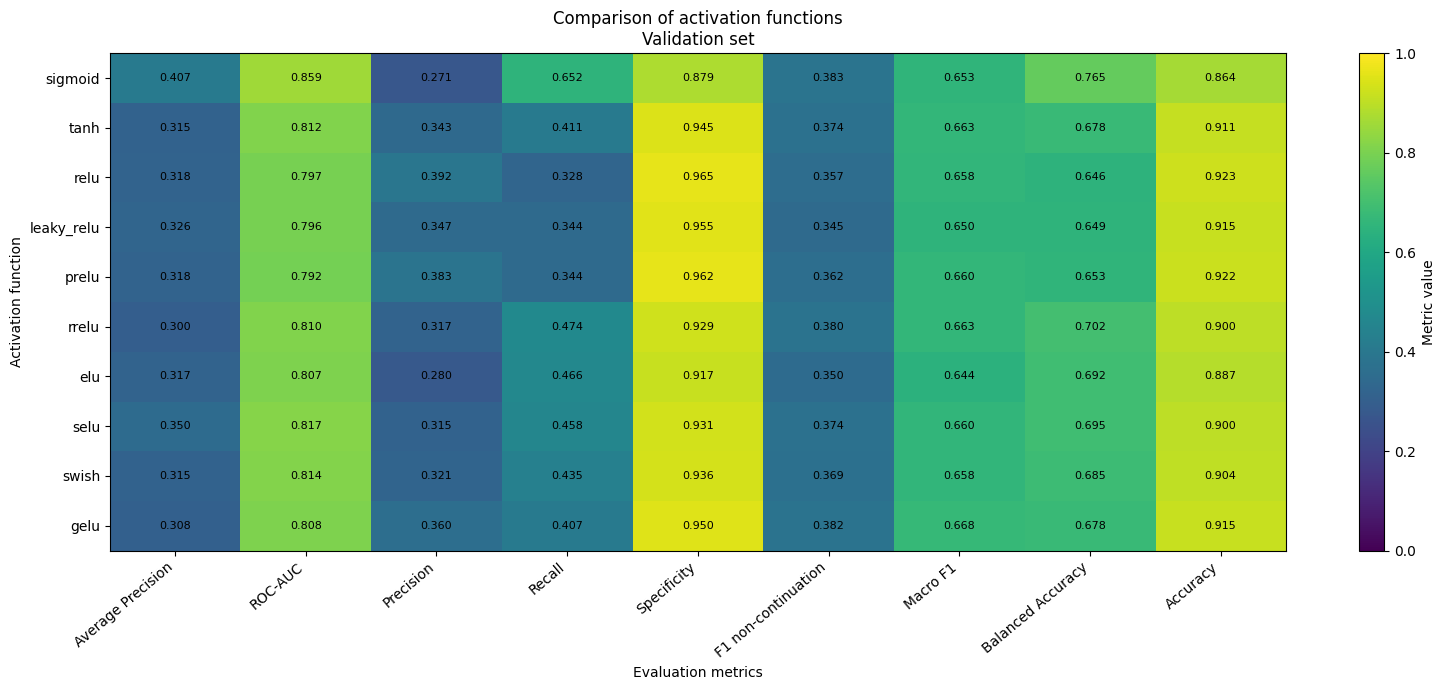

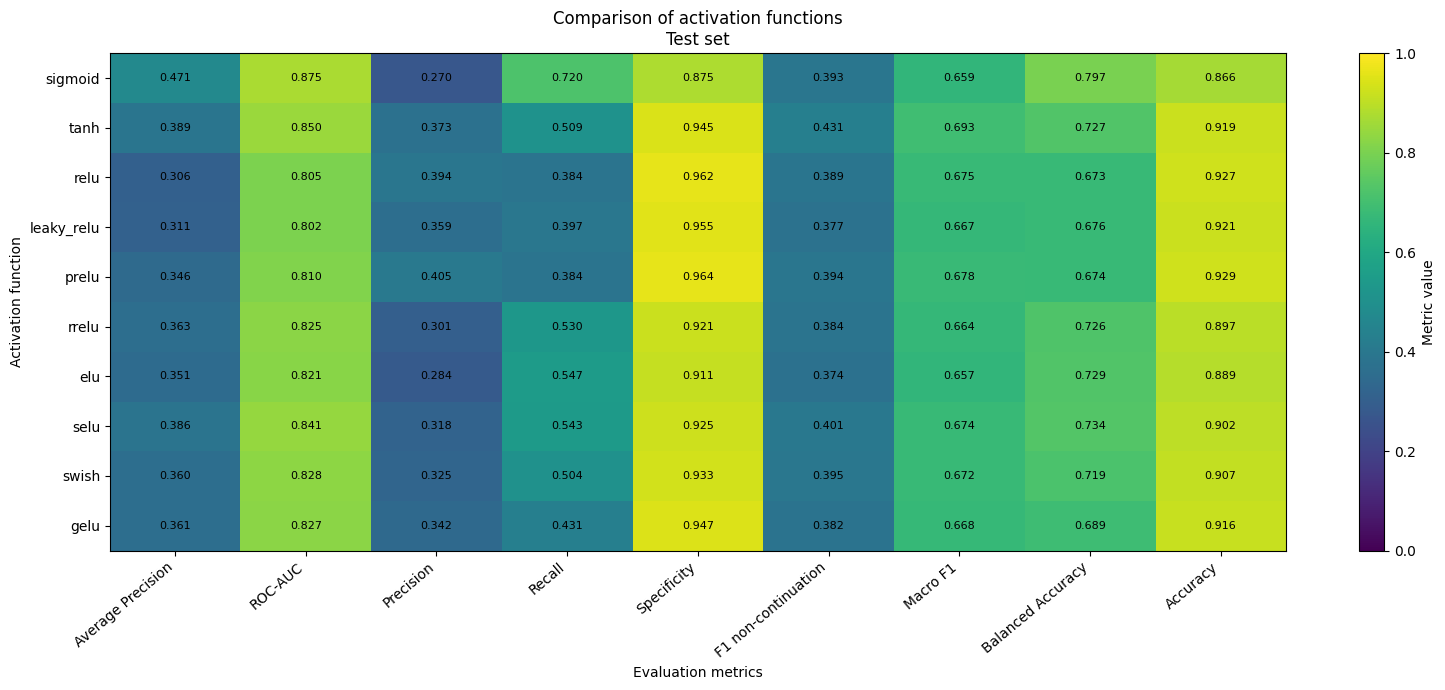

In [ ]:

METRICAS_GRAFICA = [
    "AVERAGE_PRECISION",
    "ROC_AUC",
    "PRECISION_RIESGO",
    "RECALL_RIESGO",
    "ESPECIFICIDAD",
    "F1_RIESGO",
    "F1_MACRO",
    "BALANCED_ACCURACY",
    "ACCURACY"
]

NOMBRES_METRICAS = {
    "AVERAGE_PRECISION":
        "Average Precision",

    "ROC_AUC":
        "ROC-AUC",

    "PRECISION_RIESGO":
        "Precision",

    "RECALL_RIESGO":
        "Recall",

    "ESPECIFICIDAD":
        "Specificity",

    "F1_RIESGO":
        "F1 non-continuation",

    "F1_MACRO":
        "Macro F1",

    "BALANCED_ACCURACY":
        "Balanced Accuracy",

    "ACCURACY":
        "Accuracy"
}


def graficar_mapa_calor(
    tabla: pd.DataFrame,
    nombre_conjunto: str,
    nombre_archivo: str
) -> None:

    columnas_necesarias = [
        "ACTIVACION"
    ] + METRICAS_GRAFICA

    columnas_faltantes = [
        columna
        for columna in columnas_necesarias
        if columna not in tabla.columns
    ]

    if columnas_faltantes:

        raise KeyError(
            "No se encontraron estas columnas en la tabla:\n"
            f"{columnas_faltantes}\n\n"
            "Columnas disponibles:\n"
            f"{tabla.columns.tolist()}"
        )

    tabla_mapa = (
        tabla
        .set_index(
            "ACTIVACION"
        )
        [METRICAS_GRAFICA]
        .rename(
            columns=NOMBRES_METRICAS
        )
    )


    valores = tabla_mapa.to_numpy(
        dtype=float
    )

    fig, ax = plt.subplots(
        figsize=(
            16,
            7
        )
    )


    imagen = ax.imshow(
        valores,
        aspect="auto",
        vmin=0,
        vmax=1
    )

    ax.set_xticks(
        np.arange(
            len(
                tabla_mapa.columns
            )
        )
    )

    ax.set_xticklabels(
        tabla_mapa.columns,
        rotation=40,
        ha="right"
    )


    ax.set_yticks(
        np.arange(
            len(
                tabla_mapa.index
            )
        )
    )

    ax.set_yticklabels(
        tabla_mapa.index
    )


    for fila in range(
        valores.shape[0]
    ):

        for columna in range(
            valores.shape[1]
        ):

            ax.text(
                columna,
                fila,
                f"{valores[fila, columna]:.3f}",
                ha="center",
                va="center",
                fontsize=8
            )


    ax.set_title(
        "Comparison of activation functions\n"
        f"{nombre_conjunto} set"
    )

    ax.set_xlabel(
        "Evaluation metrics"
    )

    ax.set_ylabel(
        "Activation function"
    )


    barra = fig.colorbar(
        imagen,
        ax=ax
    )

    barra.set_label(
        "Metric value"
    )


    plt.tight_layout()



    plt.savefig(
        CARPETA_GRAFICAS
        / nombre_archivo,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

graficar_mapa_calor(
    tabla_validacion,
    "Validation",
    "heatmap_validation.png"
)


graficar_mapa_calor(
    tabla_prueba,
    "Test",
    "heatmap_test.png"
)

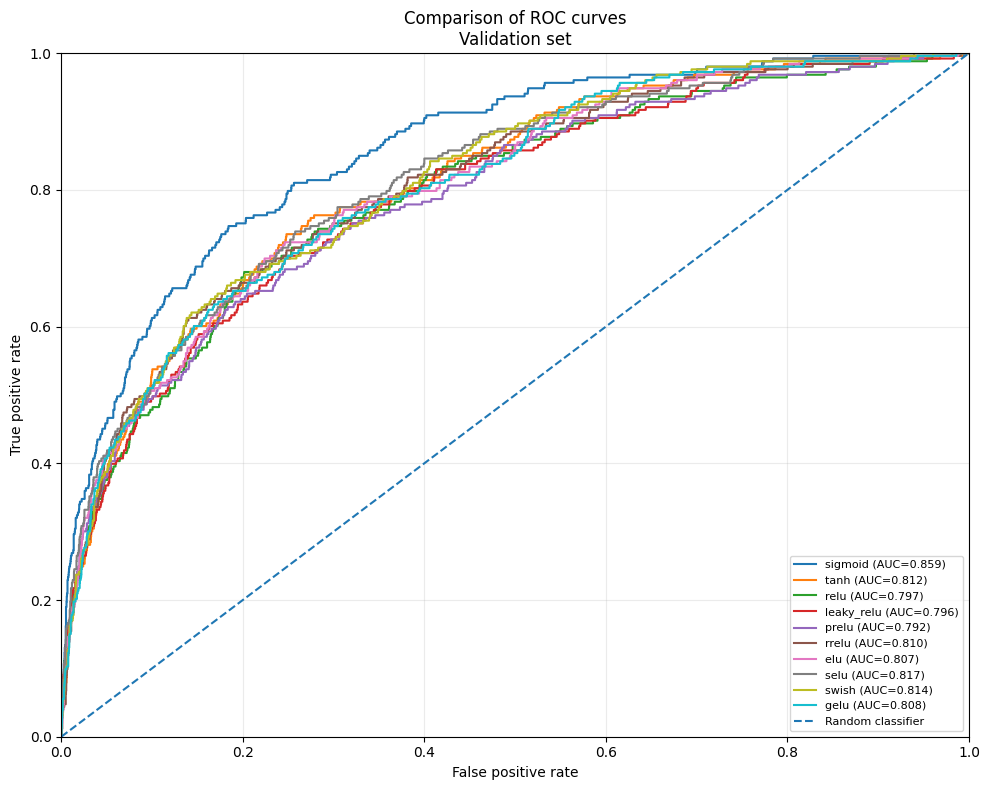

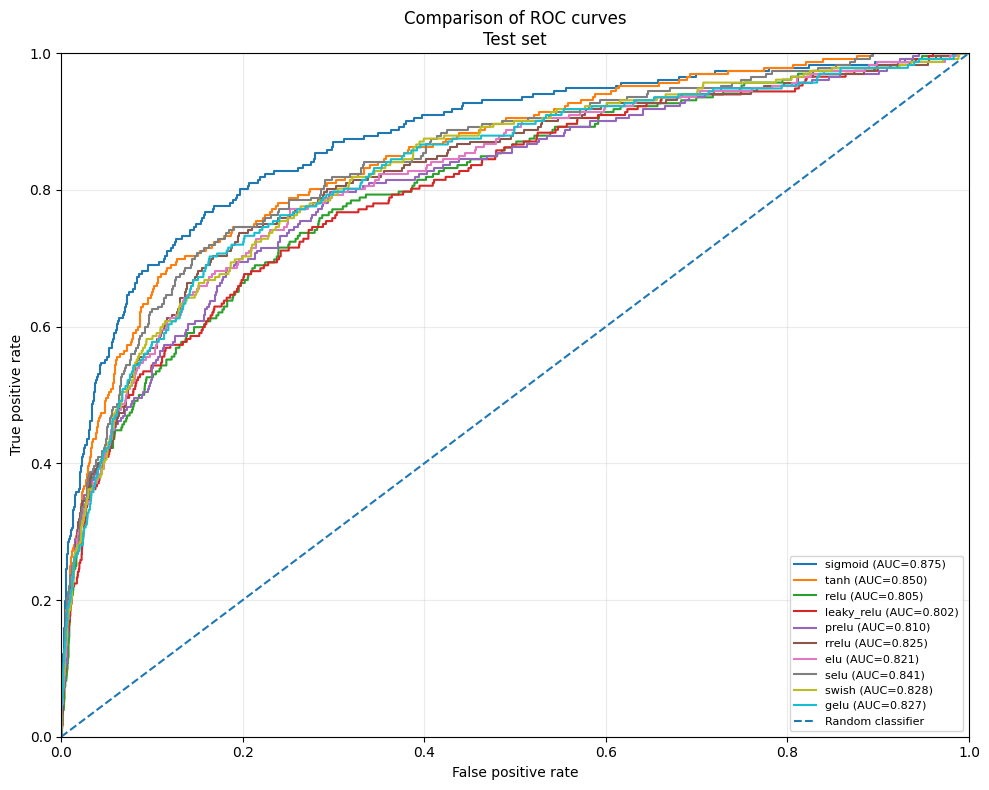

In [ ]:

def graficar_curvas_roc(
    probabilidades_modelos: dict,
    y_real: np.ndarray,
    nombre_conjunto: str,
    nombre_archivo: str
) -> None:

    plt.figure(
        figsize=(
            10,
            8
        )
    )


    for activacion in ACTIVACIONES:

        probabilidades = (
            probabilidades_modelos[
                activacion
            ]
        )


        fpr, tpr, _ = roc_curve(
            y_real,
            probabilidades
        )


        auc_roc = roc_auc_score(
            y_real,
            probabilidades
        )


        plt.plot(
            fpr,
            tpr,

            label=(
                f"{activacion} "
                f"(AUC={auc_roc:.3f})"
            )
        )


    plt.plot(
        [
            0,
            1
        ],
        [
            0,
            1
        ],
        linestyle="--",
        label="Random classifier"
    )

    plt.xlabel(
        "False positive rate"
    )

    plt.ylabel(
        "True positive rate"
    )

    plt.title(
        "Comparison of ROC curves\n"
        f"{nombre_conjunto} set"
    )


    plt.xlim(
        0,
        1
    )

    plt.ylim(
        0,
        1
    )


    plt.legend(
        loc="lower right",
        fontsize=8
    )


    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    plt.savefig(
        CARPETA_GRAFICAS
        / nombre_archivo,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

graficar_curvas_roc(
    probabilidades_modelos_val,
    y_val,
    "Validation",
    "roc_curves_validation.png"
)


graficar_curvas_roc(
    probabilidades_modelos_test,
    y_test,
    "Test",
    "roc_curves_test.png"
)

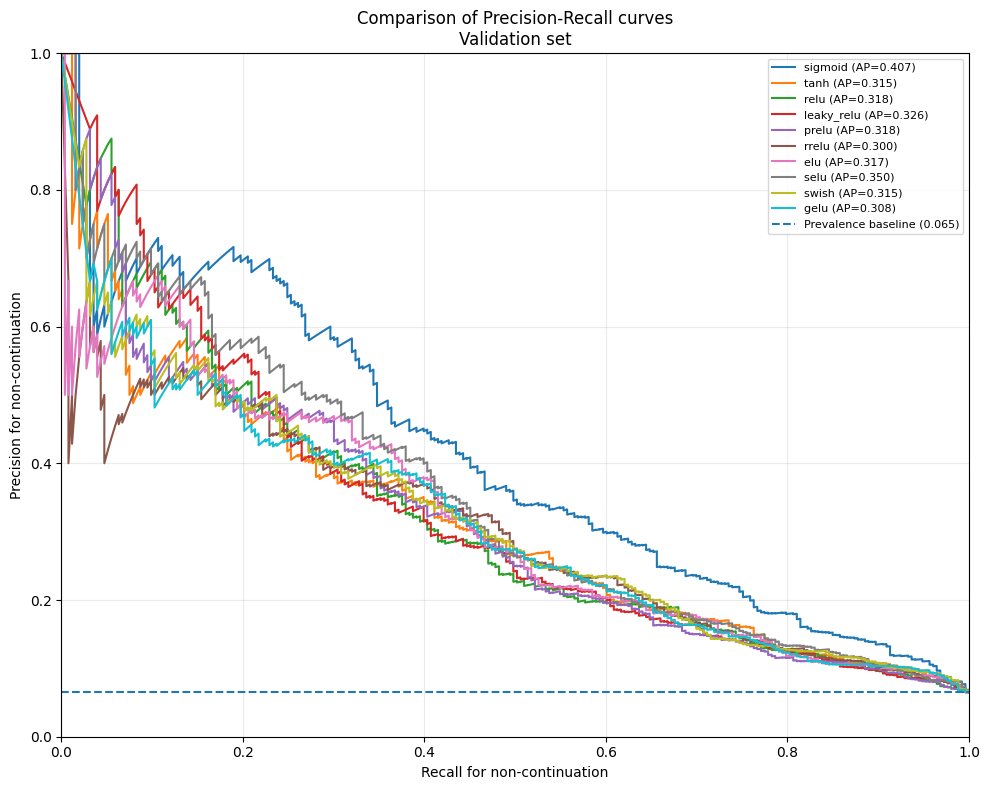

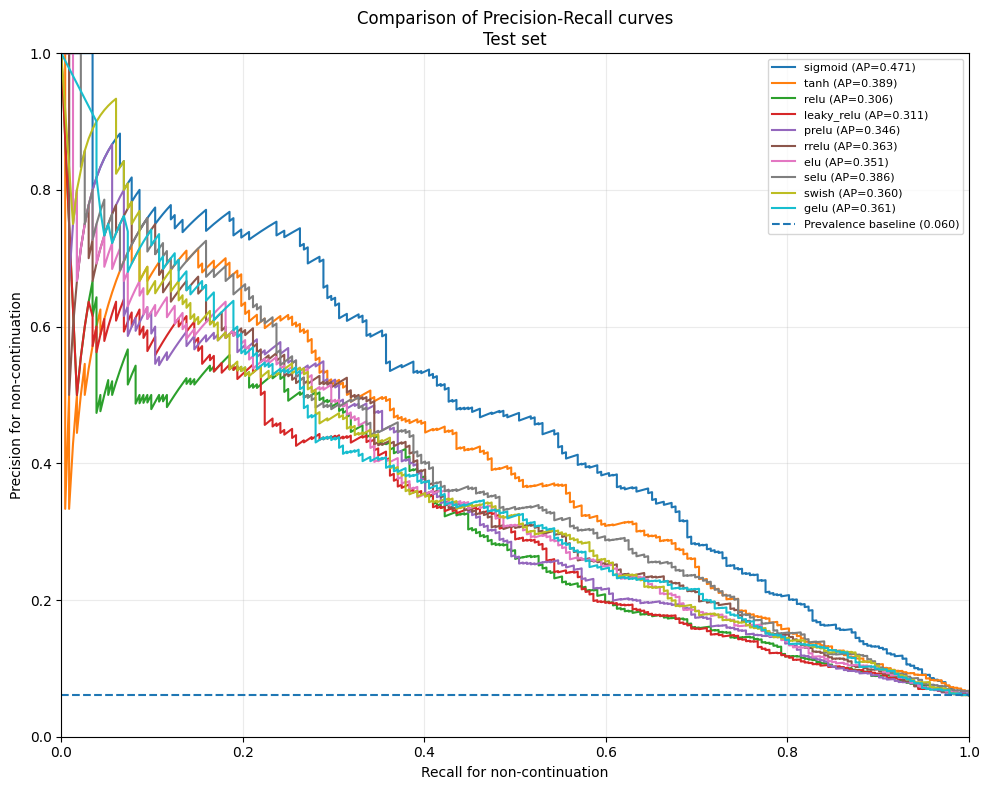

In [ ]:

def graficar_curvas_precision_recall(
    probabilidades_modelos: dict,
    y_real: np.ndarray,
    nombre_conjunto: str,
    nombre_archivo: str
) -> None:

    plt.figure(
        figsize=(
            10,
            8
        )
    )


    for activacion in ACTIVACIONES:

        probabilidades = (
            probabilidades_modelos[
                activacion
            ]
        )


        precision, recall, _ = (
            precision_recall_curve(
                y_real,
                probabilidades
            )
        )


        ap = average_precision_score(
            y_real,
            probabilidades
        )


        plt.plot(
            recall,
            precision,

            label=(
                f"{activacion} "
                f"(AP={ap:.3f})"
            )
        )


    prevalencia = float(
        np.mean(
            y_real
        )
    )


    plt.axhline(
        y=prevalencia,
        linestyle="--",

        label=(
            "Prevalence baseline "
            f"({prevalencia:.3f})"
        )
    )


    plt.xlabel(
        "Recall for non-continuation"
    )

    plt.ylabel(
        "Precision for non-continuation"
    )

    plt.title(
        "Comparison of Precision-Recall curves\n"
        f"{nombre_conjunto} set"
    )

    plt.xlim(
        0,
        1
    )

    plt.ylim(
        0,
        1
    )

    plt.legend(
        loc="best",
        fontsize=8
    )

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()


    plt.savefig(
        CARPETA_GRAFICAS
        / nombre_archivo,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


graficar_curvas_precision_recall(
    probabilidades_modelos_val,
    y_val,
    "Validation",
    "precision_recall_curves_validation.png"
)


graficar_curvas_precision_recall(
    probabilidades_modelos_test,
    y_test,
    "Test",
    "precision_recall_curves_test.png"
)

Seleccionar la mejor activación y determinar el umbral

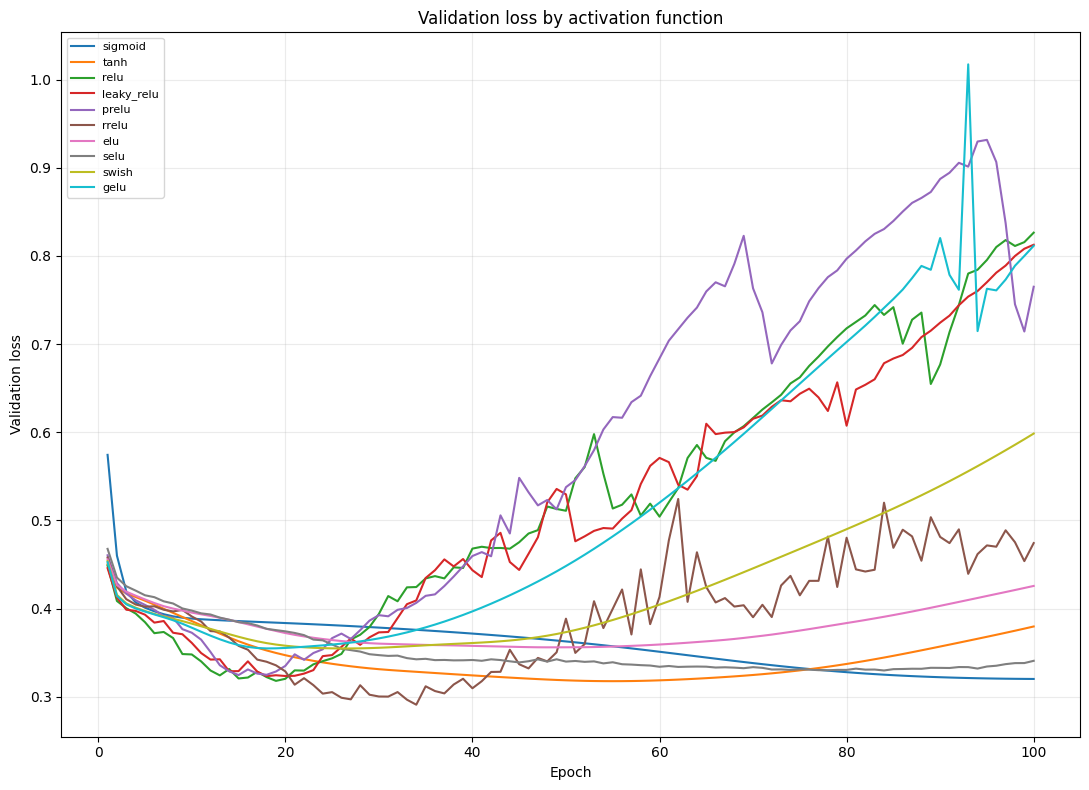

In [ ]:

plt.figure(
    figsize=(
        11,
        8
    )
)


for activacion in ACTIVACIONES:

    historial = pd.read_csv(
        CARPETA_HISTORIALES
        / f"historial_{activacion}.csv"
    )


    plt.plot(
        np.arange(
            1,
            len(
                historial
            )
            + 1
        ),

        historial[
            "val_loss"
        ],

        label=activacion
    )


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Validation loss"
)

plt.title(
    "Validation loss by activation function"
)

plt.legend(
    fontsize=8
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    CARPETA_GRAFICAS
    / "validation_loss_all_activation_functions.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

Evaluación final en prueba

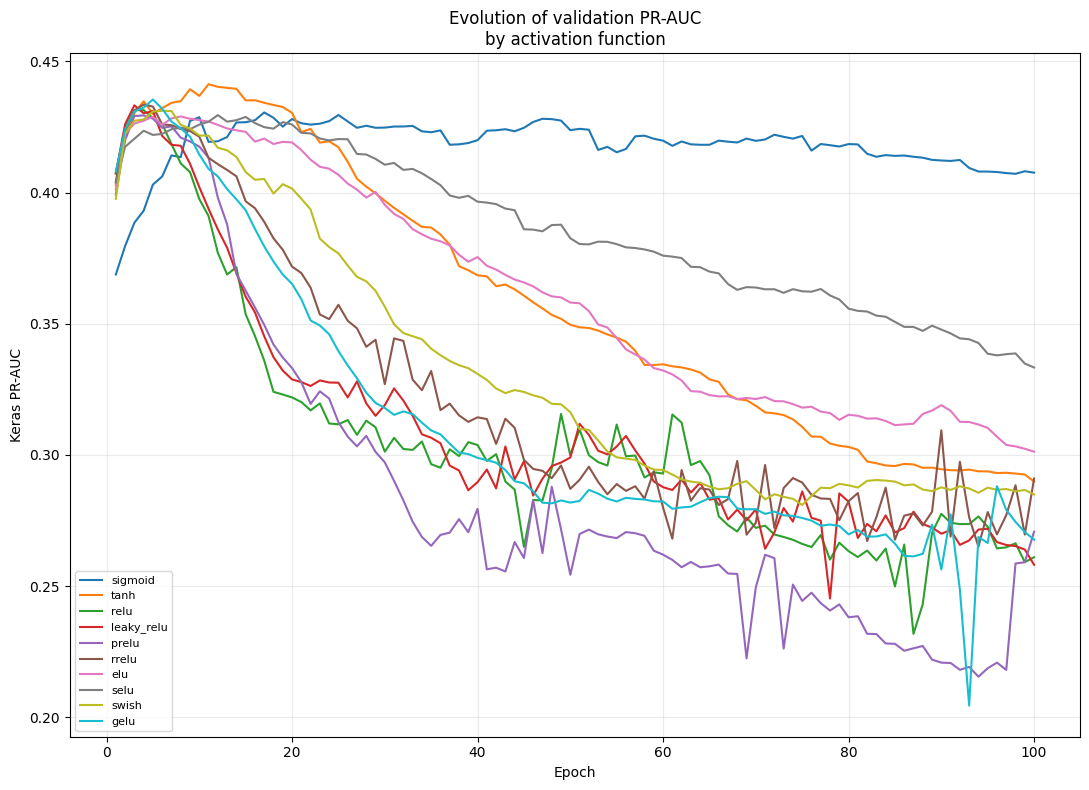

In [ ]:

plt.figure(
    figsize=(
        11,
        8
    )
)


for activacion in ACTIVACIONES:

    historial = pd.read_csv(
        CARPETA_HISTORIALES
        / f"historial_{activacion}.csv"
    )


    plt.plot(
        np.arange(
            1,
            len(
                historial
            )
            + 1
        ),

        historial[
            "val_pr_auc_keras"
        ],

        label=activacion
    )


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Keras PR-AUC"
)

plt.title(
    "Evolution of validation PR-AUC\n"
    "by activation function"
)

plt.legend(
    fontsize=8
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    CARPETA_GRAFICAS
    / "keras_pr_auc_validation_all_activation_functions.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

Gráficas y resumen final

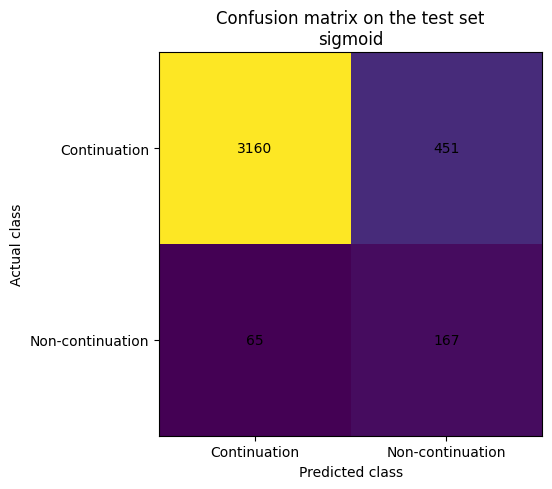

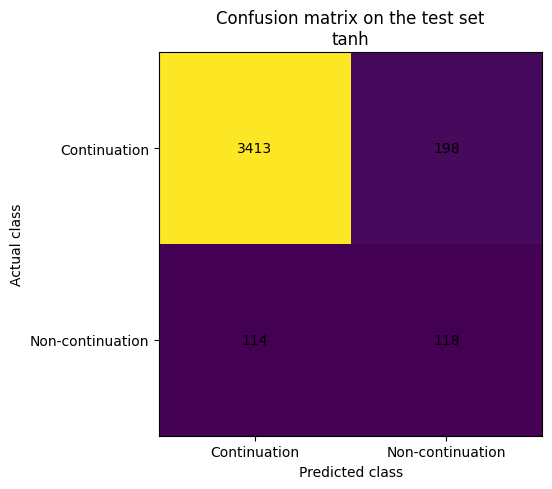

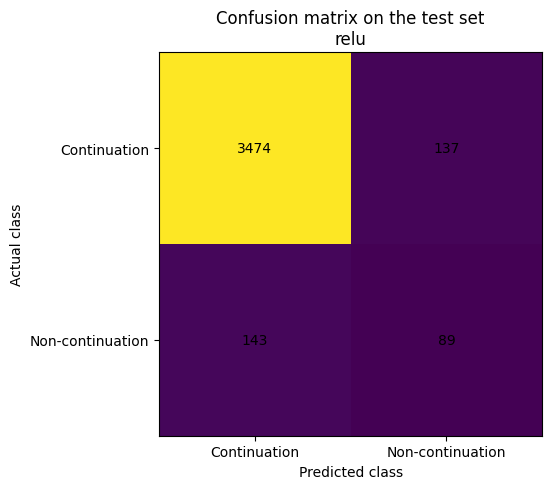

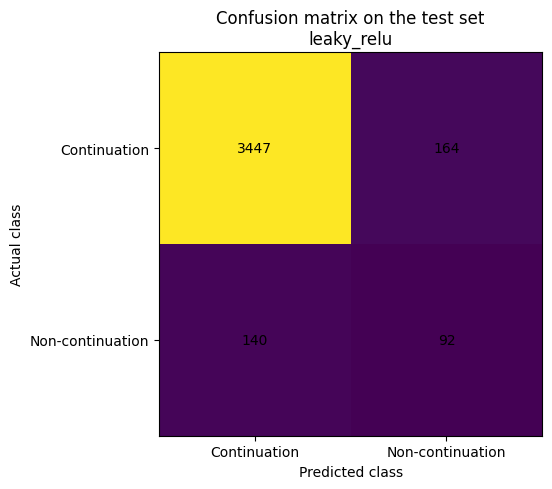

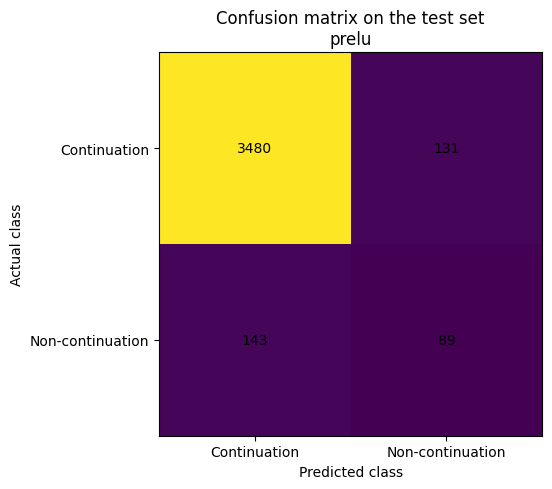

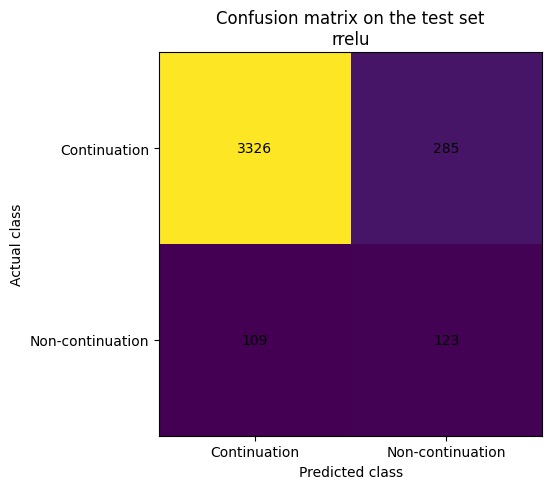

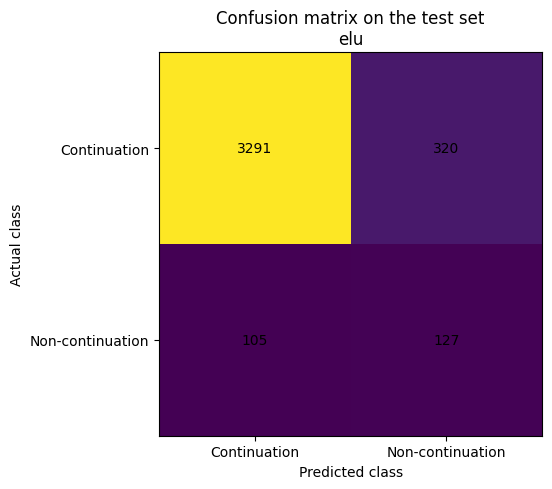

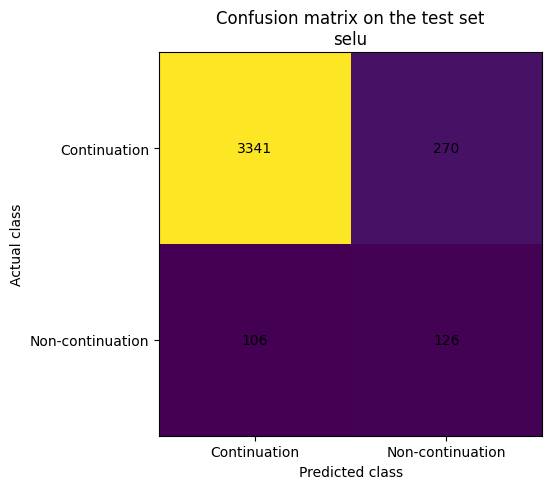

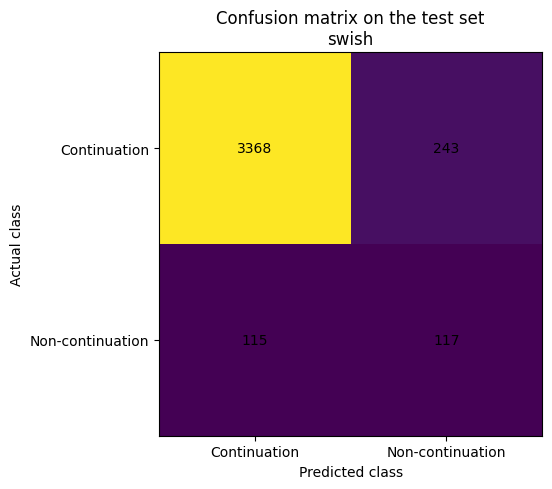

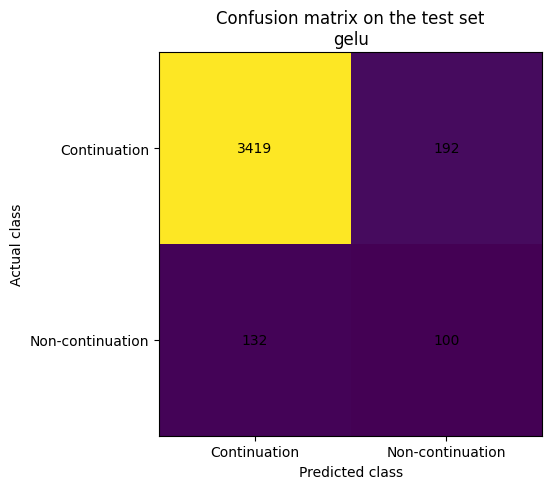

In [ ]:

for activacion in ACTIVACIONES:

    ruta_matriz = (
        CARPETA_MATRICES
        / (
            "matriz_prueba_"
            f"{activacion}.csv"
        )
    )


    matriz = (
        pd.read_csv(
            ruta_matriz,
            index_col=0
        )
        .to_numpy()
    )


    plt.figure(
        figsize=(
            6,
            5
        )
    )


    plt.imshow(
        matriz
    )


    plt.xticks(
        [
            0,
            1
        ],
        [
            "Continuation",
            "Non-continuation"
        ]
    )


    plt.yticks(
        [
            0,
            1
        ],
        [
            "Continuation",
            "Non-continuation"
        ]
    )


    plt.xlabel(
        "Predicted class"
    )

    plt.ylabel(
        "Actual class"
    )


    plt.title(
        "Confusion matrix on the test set\n"
        f"{activacion}"
    )


    for fila in range(2):

        for columna in range(2):

            plt.text(
                columna,
                fila,

                int(
                    matriz[
                        fila,
                        columna
                    ]
                ),

                ha="center",
                va="center"
            )


    plt.tight_layout()


    plt.savefig(
        CARPETA_GRAFICAS
        / (
            "confusion_matrix_test_"
            f"{activacion}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

In [ ]:

resumen_maximos = []


for metrica in METRICAS_GRAFICA:

    valor_maximo = (
        tabla_prueba[
            metrica
        ]
        .max()
    )


    activaciones_maximas = (
        tabla_prueba.loc[
            np.isclose(
                tabla_prueba[
                    metrica
                ],
                valor_maximo
            ),
            "ACTIVACION"
        ]
        .tolist()
    )

    nombre_metrica = (
        NOMBRES_METRICAS.get(
            metrica,
            metrica
        )
    )


    resumen_maximos.append({
        "METRIC":
            nombre_metrica,

        "MAXIMUM_VALUE":
            float(
                valor_maximo
            ),

        "ACTIVATION_FUNCTIONS":
            ", ".join(
                activaciones_maximas
            )
    })


tabla_maximos = pd.DataFrame(
    resumen_maximos
)


tabla_maximos.to_csv(
    CARPETA_RESULTADOS
    / "highest_values_by_metric_test_set.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    tabla_maximos
    .round(4)
    .to_string(
        index=False
    )
)

             METRIC  MAXIMUM_VALUE ACTIVATION_FUNCTIONS
  Average Precision         0.4710              sigmoid
            ROC-AUC         0.8749              sigmoid
          Precision         0.4045                prelu
             Recall         0.7198              sigmoid
        Specificity         0.9637                prelu
F1 non-continuation         0.4307                 tanh
           Macro F1         0.6935                 tanh
  Balanced Accuracy         0.7975              sigmoid
           Accuracy         0.9287                prelu


In [ ]:

configuracion = {
    "experiment_objective":
        (
            "Compare the performance of ten "
            "activation functions"
        ),

    "single_model_selection":
        False,

    "activation_functions":
        ACTIVACIONES,

    "architecture":
        [
            64,
            32,
            1
        ],

    "output_activation":
        "sigmoid",

    "positive_class":
        "Educational non-continuation",

    "class_encoding":
        {
            "continuation":
                0,

            "non_continuation":
                1
        },

    "fixed_threshold":
        float(
            UMBRAL_DECISION
        ),

    "optimizer":
        "Adam",

    "learning_rate":
        float(
            TASA_APRENDIZAJE
        ),

    "loss_function":
        "binary_crossentropy",

    "number_of_epochs":
        int(
            NUMERO_EPOCAS
        ),

    "early_stopping":
        False,

    "model_checkpoint":
        False,

    "internal_weights_criterion":
        (
            "Weights obtained at the end "
            "of epoch 100"
        ),

    "batch_size":
        int(
            TAMANIO_LOTE
        ),

    "split_seed":
        int(
            SEMILLA_PARTICION
        ),

    "model_seed":
        int(
            SEMILLA_MODELO
        ),

    "data_splits":
        {
            "training":
                0.60,

            "validation":
                0.20,

            "test":
                0.20
        },

    "grouped_split_by":
        "FOLIO",

    "number_of_encoded_predictors":
        int(
            X_train.shape[1]
        ),

    "class_weights":
        {
            str(clase):
                float(peso)

            for clase, peso
            in pesos_clase.items()
        },

    "expansion_factor_as_predictor":
        False,

    "leaky_relu_negative_slope":
        0.01,

    "prelu_initial_alpha":
        0.25,

    "prelu_shared_slope":
        True,

    "rrelu_lower":
        float(
            1.0 / 8.0
        ),

    "rrelu_upper":
        float(
            1.0 / 3.0
        ),

    "software_versions":
        {
            "python":
                sys.version,

            "tensorflow":
                tf.__version__,

            "keras":
                keras.__version__,

            "scikit_learn":
                sklearn.__version__,

            "pandas":
                pd.__version__,

            "numpy":
                np.__version__
        }
}


ruta_configuracion = (
    CARPETA_RESULTADOS
    / "experiment_configuration.json"
)


with open(
    ruta_configuracion,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        configuracion,
        archivo,
        indent=4,
        ensure_ascii=False
    )


print(
    "\n"
    + "=" * 65
)

print(
    "PROCESS COMPLETED"
)

print(
    "=" * 65
)


print(
    "Activation functions evaluated:",
    len(ACTIVACIONES)
)

print(
    "Epochs per model:",
    NUMERO_EPOCAS
)

print(
    "Fixed threshold:",
    UMBRAL_DECISION
)

print(
    "Encoded predictors:",
    X_train.shape[1]
)

print(
    "\nNo universally best activation "
    "function was selected."
)

print(
    "\nResults saved in:"
)

print(
    CARPETA_RESULTADOS
)


PROCESS COMPLETED
Activation functions evaluated: 10
Epochs per model: 100
Fixed threshold: 0.5
Encoded predictors: 136

No universally best activation function was selected.

Results saved in:
/content/drive/MyDrive/RNA_ENAPE/datos_RNA/enape_2021_bd_csv/resultados_rna_100_epocas


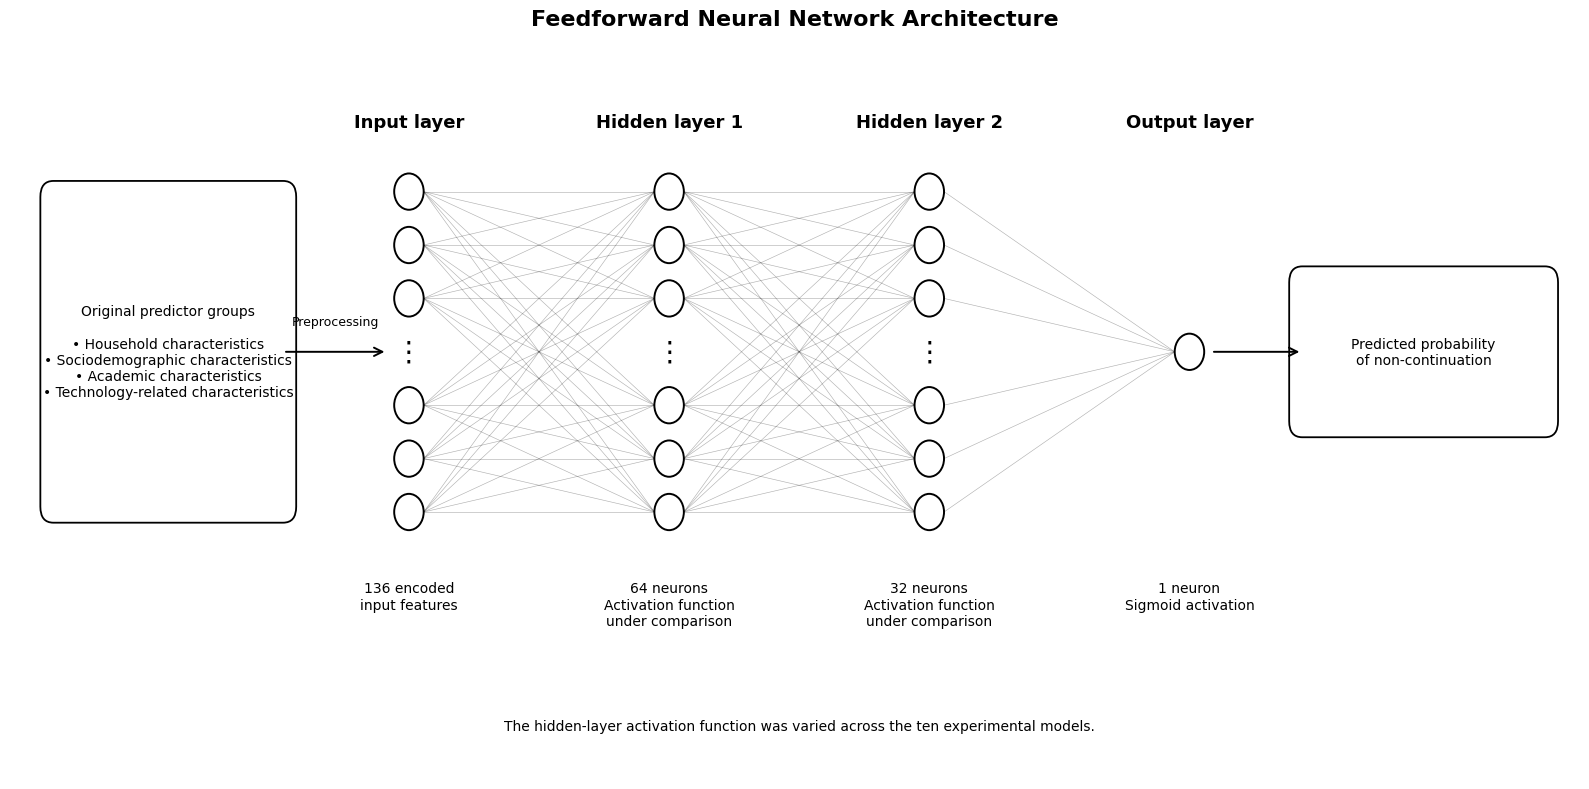

In [ ]:

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import (
    Circle,
    FancyArrowPatch,
    FancyBboxPatch
)


INPUT_DIM = int(
    X_train.shape[1]
)

ACTIVATION_LABEL = (
    "Activation function\n"
    "under comparison"
)

INPUT_VARIABLE_GROUPS = [
    "Household characteristics",
    "Sociodemographic characteristics",
    "Academic characteristics",
    "Technology-related characteristics"
]

layers = [
    {
        "x": 0.0,
        "title": "Input layer",
        "subtitle": (
            f"{INPUT_DIM} encoded\n"
            "input features"
        ),
        "neurons": INPUT_DIM
    },

    {
        "x": 3.0,
        "title": "Hidden layer 1",
        "subtitle": (
            "64 neurons\n"
            f"{ACTIVATION_LABEL}"
        ),
        "neurons": 64
    },

    {
        "x": 6.0,
        "title": "Hidden layer 2",
        "subtitle": (
            "32 neurons\n"
            f"{ACTIVATION_LABEL}"
        ),
        "neurons": 32
    },

    {
        "x": 9.0,
        "title": "Output layer",
        "subtitle": (
            "1 neuron\n"
            "Sigmoid activation"
        ),
        "neurons": 1
    }
]


def get_neuron_positions(
    number_of_neurons: int
) -> np.ndarray:

    if number_of_neurons == 1:

        return np.array([
            0.0
        ])

  
    return np.array([
        -1.50,
        -1.00,
        -0.50,
        0.50,
        1.00,
        1.50
    ])


fig, ax = plt.subplots(
    figsize=(
        16,
        8
    )
)


neuron_radius = 0.17

for layer_index in range(
    len(layers) - 1
):

    current_layer = layers[
        layer_index
    ]

    next_layer = layers[
        layer_index + 1
    ]

    current_positions = (
        get_neuron_positions(
            current_layer[
                "neurons"
            ]
        )
    )

    next_positions = (
        get_neuron_positions(
            next_layer[
                "neurons"
            ]
        )
    )


    for current_y in current_positions:

        for next_y in next_positions:

            ax.plot(
                [
                    current_layer["x"]
                    + neuron_radius,

                    next_layer["x"]
                    - neuron_radius
                ],

                [
                    current_y,
                    next_y
                ],

                linewidth=0.45,
                alpha=0.30,
                color="black",
                zorder=1
            )

for layer in layers:

    y_positions = (
        get_neuron_positions(
            layer[
                "neurons"
            ]
        )
    )


    for y_position in y_positions:

        neuron = Circle(
            (
                layer["x"],
                y_position
            ),

            radius=neuron_radius,
            facecolor="white",
            edgecolor="black",
            linewidth=1.4,
            zorder=3
        )

        ax.add_patch(
            neuron
        )


    if layer["neurons"] > len(y_positions):

        ax.text(
            layer["x"],
            0,
            "⋮",
            ha="center",
            va="center",
            fontsize=20,
            zorder=4
        )


    ax.text(
        layer["x"],
        2.15,
        layer["title"],
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold"
    )


    ax.text(
        layer["x"],
        -2.15,
        layer["subtitle"],
        ha="center",
        va="top",
        fontsize=10
    )

predictor_text = (
    "Original predictor groups\n\n"
    + "\n".join(
        f"• {group}"
        for group in INPUT_VARIABLE_GROUPS
    )
)


predictor_box = FancyBboxPatch(
    (
        -4.10,
        -1.45
    ),

    width=2.65,
    height=2.90,

    boxstyle=(
        "round,pad=0.15"
    ),

    facecolor="white",
    edgecolor="black",
    linewidth=1.3
)

ax.add_patch(
    predictor_box
)


ax.text(
    -2.775,
    0,
    predictor_text,
    ha="center",
    va="center",
    fontsize=10
)


predictor_arrow = FancyArrowPatch(
    posA=(
        -1.45,
        0
    ),

    posB=(
        -0.25,
        0
    ),

    arrowstyle="->",
    mutation_scale=15,
    linewidth=1.4,
    color="black"
)

ax.add_patch(
    predictor_arrow
)


ax.text(
    -0.85,
    0.25,
    "Preprocessing",
    ha="center",
    fontsize=9
)


output_box = FancyBboxPatch(
    (
        10.30,
        -0.65
    ),

    width=2.80,
    height=1.30,

    boxstyle=(
        "round,pad=0.15"
    ),

    facecolor="white",
    edgecolor="black",
    linewidth=1.3
)

ax.add_patch(
    output_box
)


ax.text(
    11.70,
    0,
    (
        "Predicted probability\n"
        "of non-continuation"
    ),
    ha="center",
    va="center",
    fontsize=10
)


output_arrow = FancyArrowPatch(
    posA=(
        9.25,
        0
    ),

    posB=(
        10.30,
        0
    ),

    arrowstyle="->",
    mutation_scale=15,
    linewidth=1.4,
    color="black"
)

ax.add_patch(
    output_arrow
)

ax.set_title(
    "Feedforward Neural Network Architecture",
    fontsize=16,
    fontweight="bold",
    pad=20
)


ax.text(
    4.50,
    -3.50,
    (
        "The hidden-layer activation function was varied "
        "across the ten experimental models."
    ),
    ha="center",
    va="center",
    fontsize=10
)


ax.set_xlim(
    -4.60,
    13.50
)

ax.set_ylim(
    -4.00,
    2.80
)

ax.axis(
    "off"
)


plt.tight_layout()

CARPETA_GRAFICAS.mkdir(
    parents=True,
    exist_ok=True
)


plt.savefig(
    CARPETA_GRAFICAS
    / "neural_network_architecture.png",
    dpi=300,
    bbox_inches="tight"
)


plt.savefig(
    CARPETA_GRAFICAS
    / "neural_network_architecture.pdf",
    bbox_inches="tight"
)


plt.show()